In [2]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install plotly
!pip install scikit-learn
!pip install missingno
!pip install geopy
!pip install shap

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

pd.set_option("display.max_columns",None)

plt.style.use("ggplot")

In [5]:
restaurants = pd.read_csv("restaurants.csv")

riders = pd.read_csv("riders.csv")

orders = pd.read_csv("orders.csv")

In [6]:
restaurants.head()

riders.head()

orders.head()

,id,restaurant_id,rider_id,drop_lat,drop_lon,order_size,order_value,timestamp,promised_eta,actual_delivery_time_min,order_status,promo_code_used
0,1,1921,5764.0,12.967183,77.601366,7,843.86,2026-05-06 19:22:36,15.0,22.2,delivered,BLR10
1,2,417,3377.0,12.985586,77.615225,1,156.37,18/05/2026 22:56,15.0,19.2,delivered,WELCOME50
2,3,692,3424.0,12.956571,77.608251,2,290.15,05/06/2026 19:20,20.0,20.1,delivered,WELCOME50
3,4,140,861.0,12.950077,77.590249,2,164.77,2026-05-16 19:39:57,20.0,18.6,delivered,NaN
4,5,189,4881.0,12.972294,77.579577,2,384.46,2026-05-19 19:50:36,20.0,20.1,delivered,NaN


In [8]:
print(restaurants.shape)

print(riders.shape)

print(orders.shape)

(4266, 8)
(6400, 8)
(307500, 12)


In [9]:
restaurants.info()

riders.info()

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4266 entries, 0 to 4265
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               4266 non-null   int64  
 1   name             4266 non-null   object 
 2   lat              4266 non-null   float64
 3   lon              4266 non-null   float64
 4   cuisine          4266 non-null   object 
 5   avg_rating       3923 non-null   float64
 6   prep_capacity    4266 non-null   int64  
 7   manager_contact  3677 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 266.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                6400 non-null   int64  
 1   lat               6400 non-null   float64
 2   lon               6400 non-null   float64
 3   vehicle_type      6160 n

In [10]:
data = orders.merge(
    restaurants,
    left_on="restaurant_id",
    right_on="id",
    how="left",
    suffixes=("", "_restaurant")
)

data = data.merge(
    riders,
    left_on="rider_id",
    right_on="id",
    how="left",
    suffixes=("", "_rider")
)

In [13]:
print(data.head())
print(data.shape)

   id  restaurant_id  rider_id   drop_lat   drop_lon  order_size  order_value  \
0   1           1921    5764.0  12.967183  77.601366           7       843.86   
1   2            417    3377.0  12.985586  77.615225           1       156.37   
2   3            692    3424.0  12.956571  77.608251           2       290.15   
3   3            692    3424.0  12.956571  77.608251           2       290.15   
4   4            140     861.0  12.950077  77.590249           2       164.77   

             timestamp  promised_eta  actual_delivery_time_min order_status  \
0  2026-05-06 19:22:36          15.0                      22.2    delivered   
1     18/05/2026 22:56          15.0                      19.2    delivered   
2     05/06/2026 19:20          20.0                      20.1    delivered   
3     05/06/2026 19:20          20.0                      20.1    delivered   
4  2026-05-16 19:39:57          20.0                      18.6    delivered   

  promo_code_used  id_restaurant      

In [14]:
data.isnull().sum().sort_values(ascending=False)

,0
promo_code_used,195218
manager_contact,59190
rider_call_sign,49989
avg_rating,35638
actual_delivery_time_min,32489
vehicle_type,28237
promised_eta,19818
id_rider,14359
lon_rider,14359
completed_orders,14359


In [15]:
missing = data.isnull().mean()*100

missing.sort_values(ascending=False)

,0
promo_code_used,50.198642
manager_contact,15.220203
rider_call_sign,12.854245
avg_rating,9.164007
actual_delivery_time_min,8.354269
vehicle_type,7.260903
promised_eta,5.096029
id_rider,3.692294
lon_rider,3.692294
completed_orders,3.692294


<Axes: >

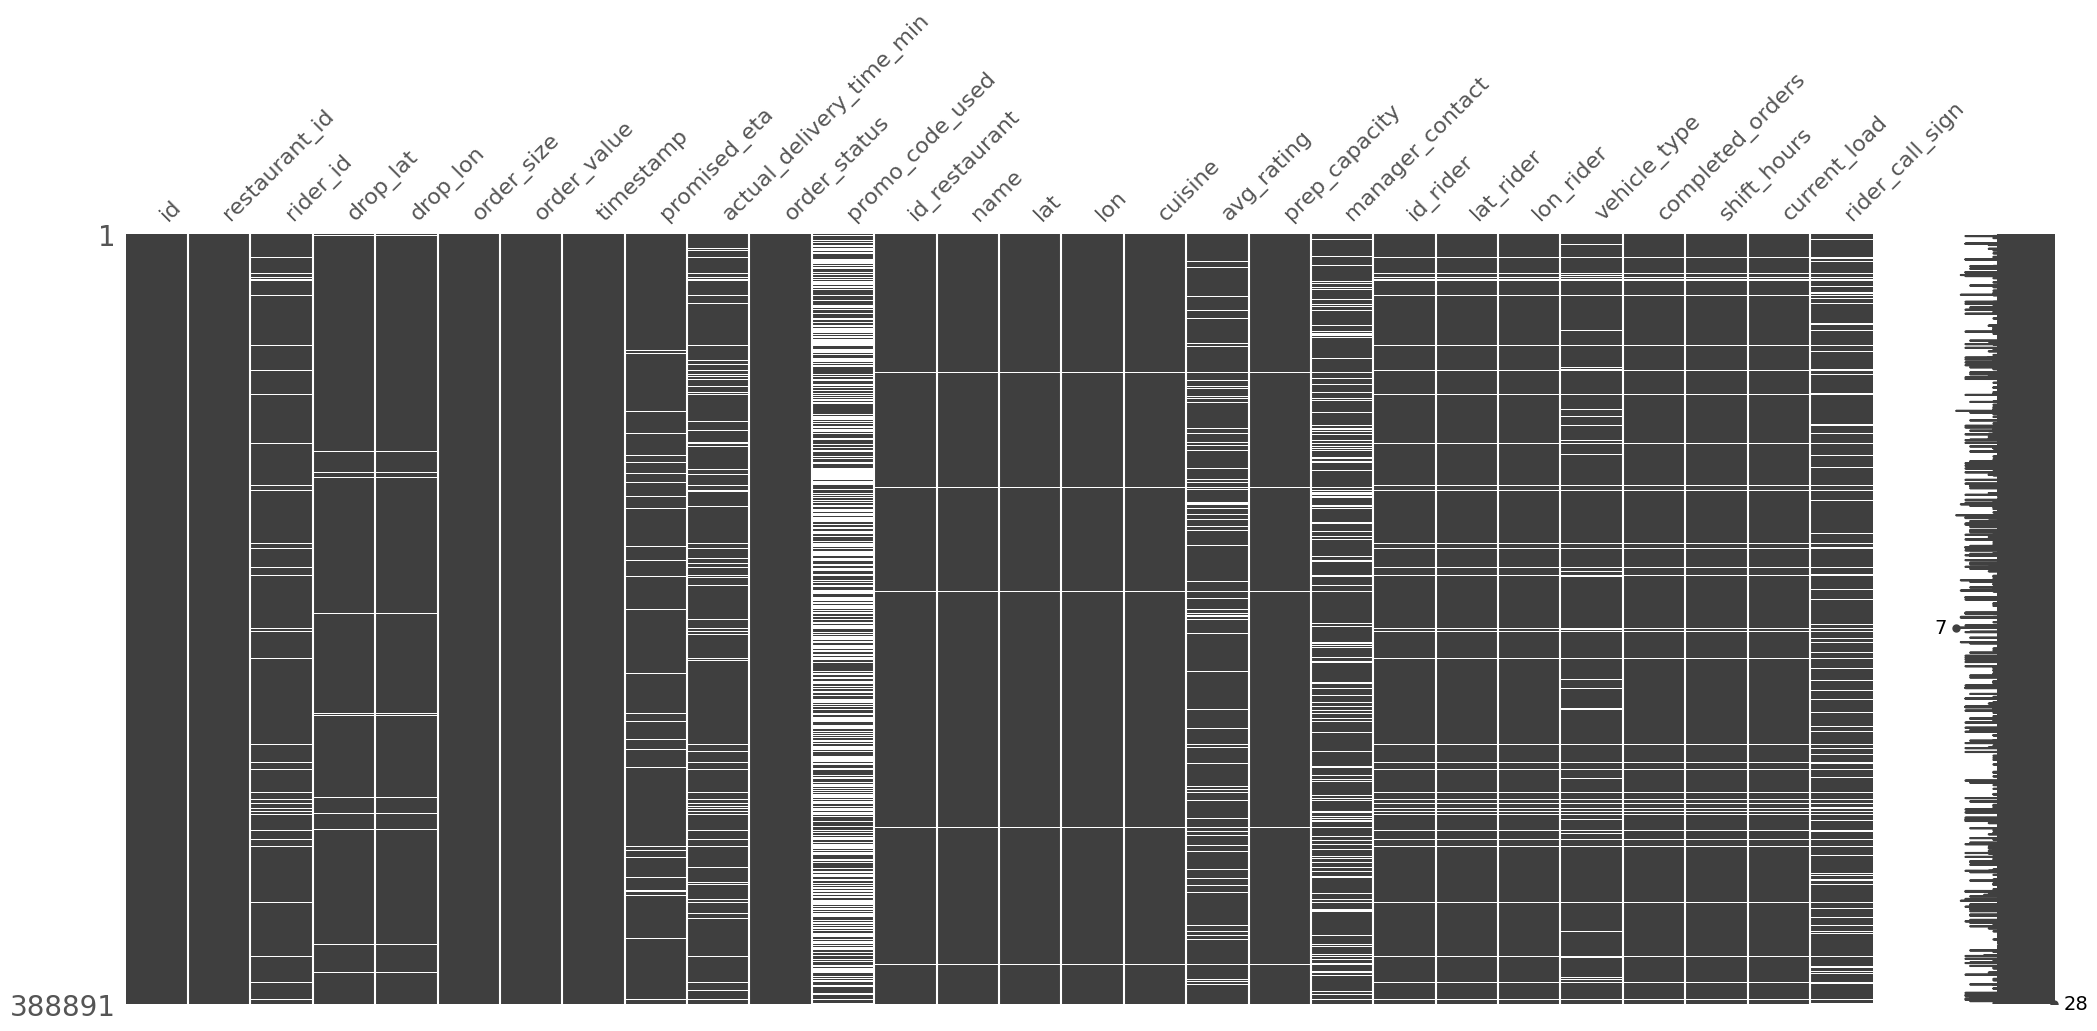

In [16]:
msno.matrix(data)

In [17]:
data.duplicated().sum()

np.int64(88891)

In [18]:
data = data.drop_duplicates()

In [19]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,300000.0,150000.500000,86602.684716,1.000000,75000.750000,150000.500000,225000.250000,300000.000000
restaurant_id,300000.0,2132.701557,1594.612222,1.000000,1018.000000,2030.000000,3038.000000,13000.000000
rider_id,287547.0,2997.516559,1732.384200,1.000000,1503.000000,3000.000000,4493.000000,6000.000000
drop_lat,294046.0,12.995556,0.381312,12.949600,12.960609,12.971650,12.982730,19.199735
drop_lon,294046.0,77.575886,0.297692,72.701678,77.583489,77.594508,77.605538,77.616600
order_size,300000.0,2.922900,1.816315,0.000000,1.000000,2.000000,4.000000,8.000000
order_value,300000.0,444.001178,319.840747,-1756.960000,211.100000,376.340000,610.122500,1806.620000
promised_eta,284693.0,29.998788,139.465591,10.000000,15.000000,20.000000,25.000000,3860.000000
actual_delivery_time_min,273598.0,35.929424,173.016825,8.000000,19.200000,24.400000,30.600000,4828.200000
id_restaurant,295455.0,1996.070285,1152.820570,1.000000,1004.000000,1998.000000,2990.000000,4000.000000


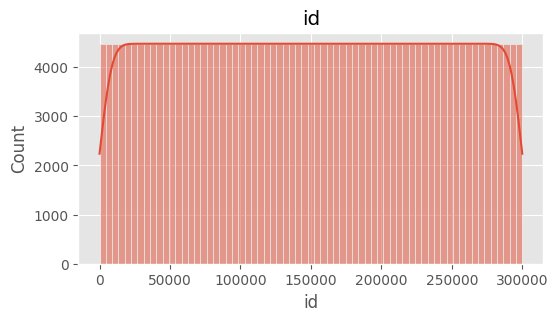

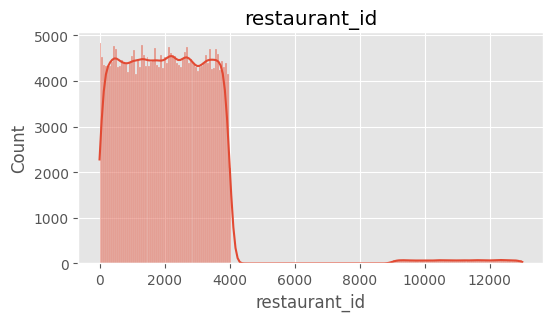

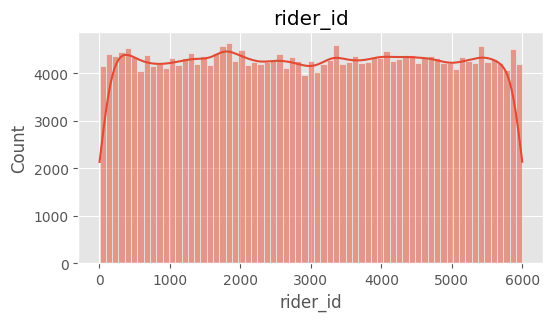

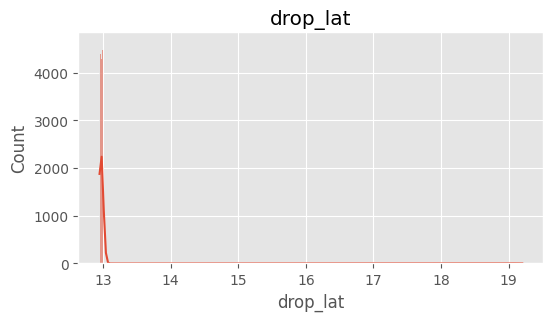

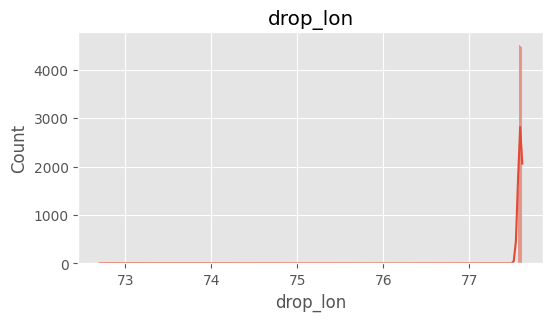

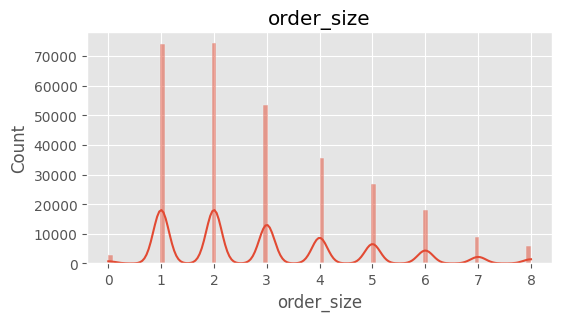

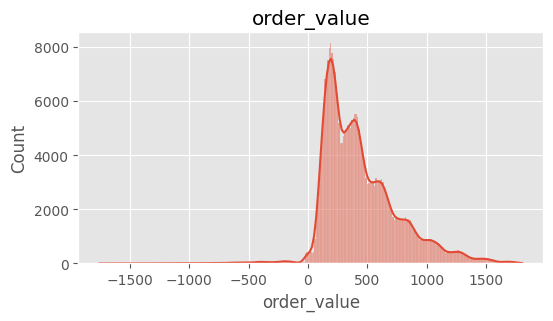

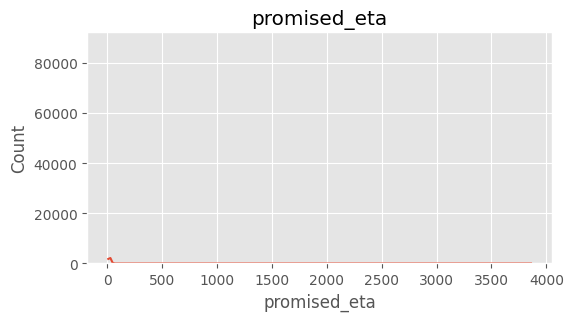

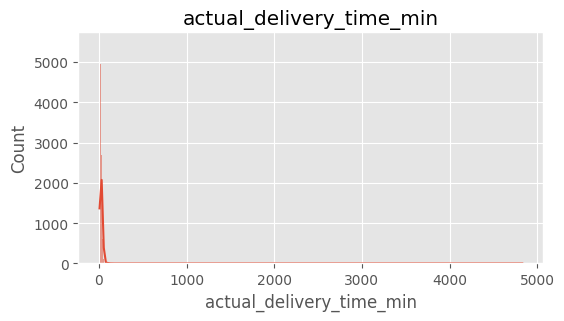

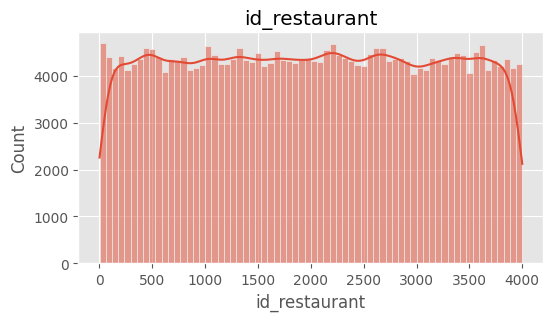

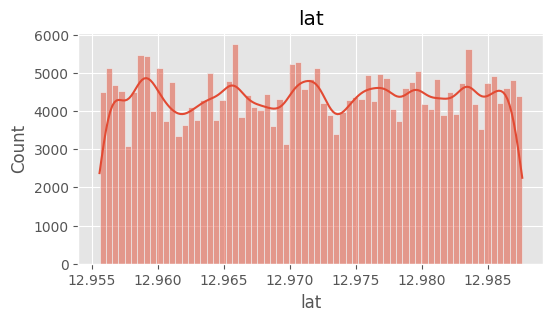

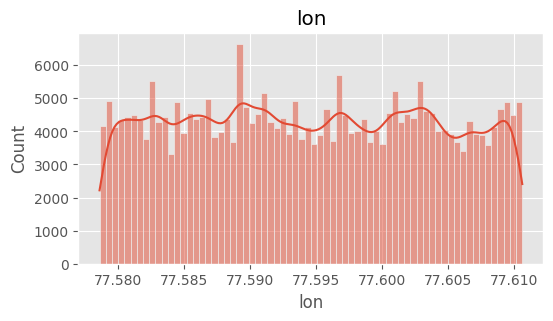

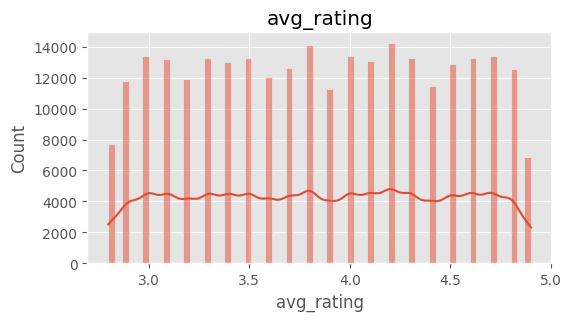

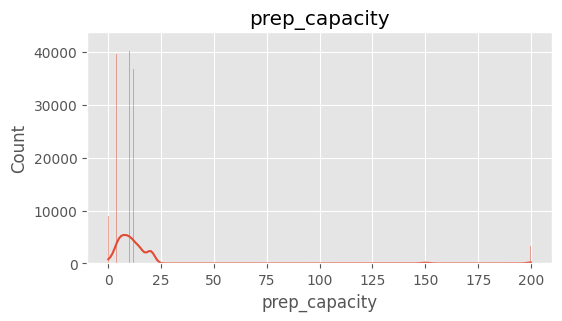

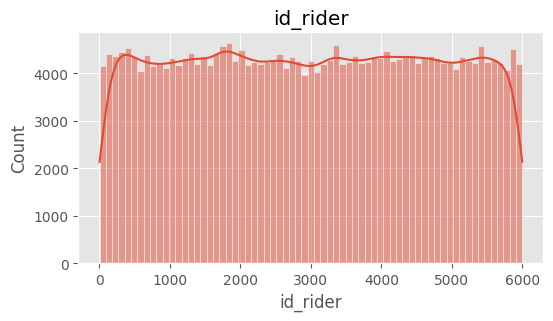

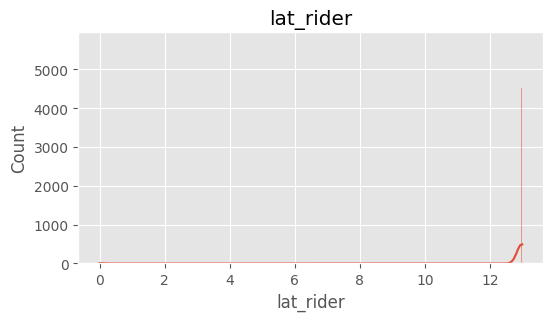

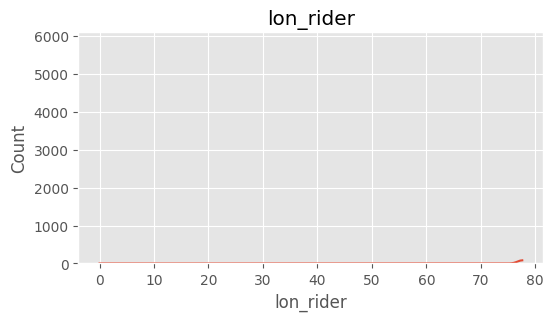

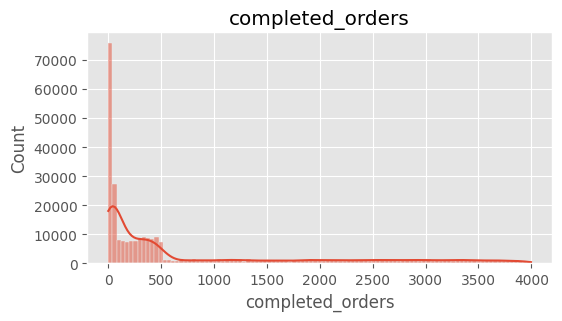

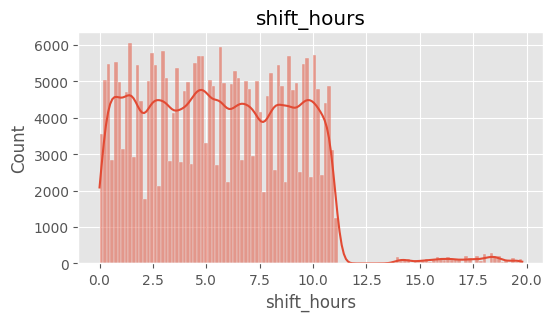

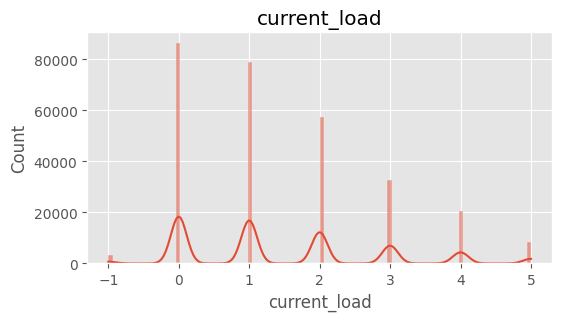

In [20]:
num_cols = data.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

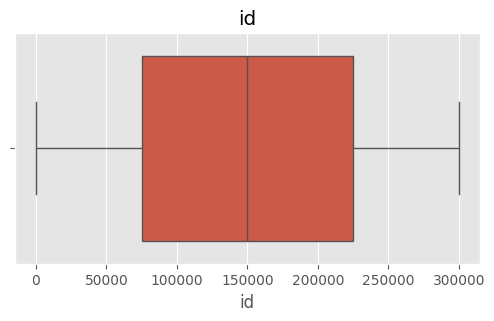

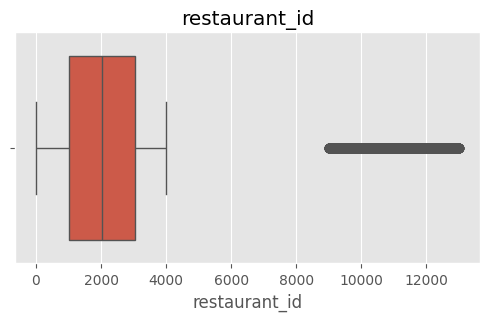

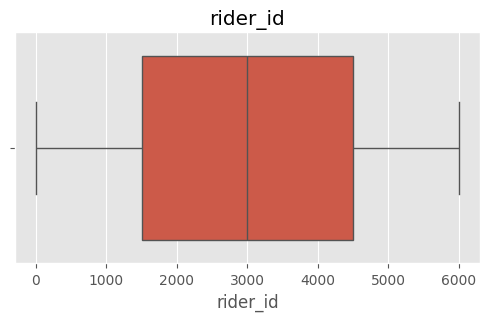

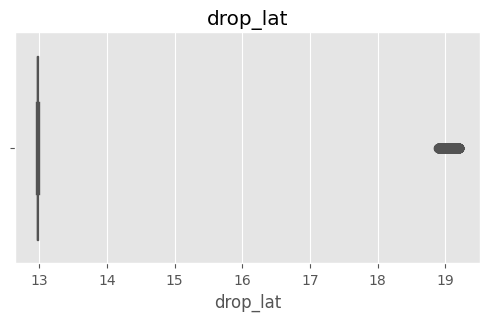

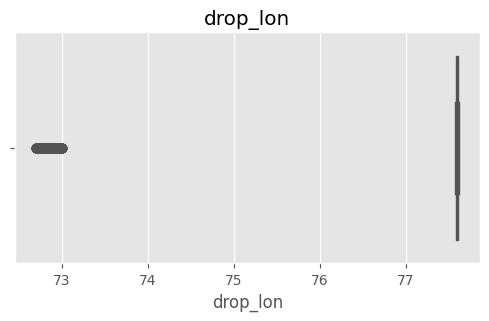

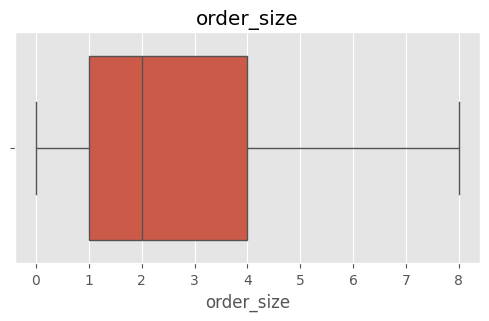

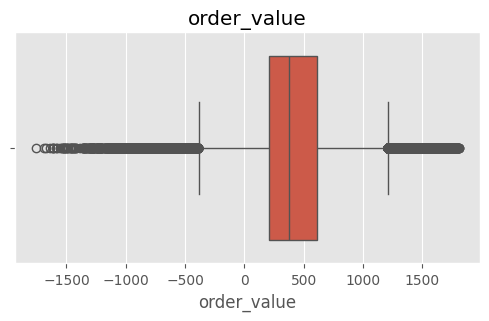

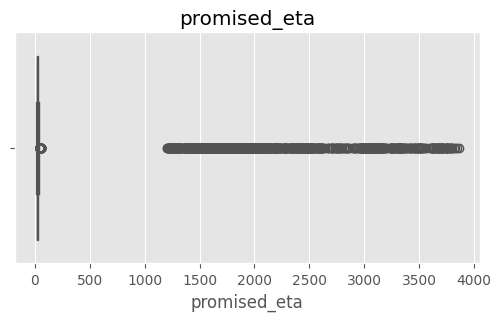

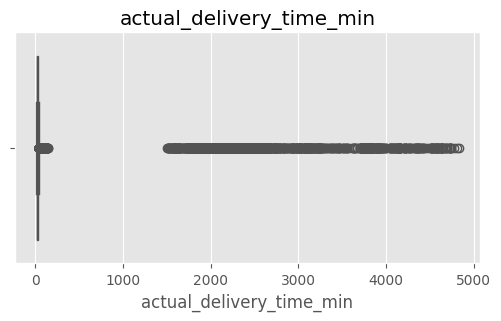

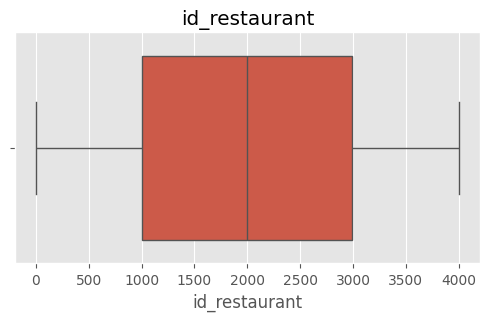

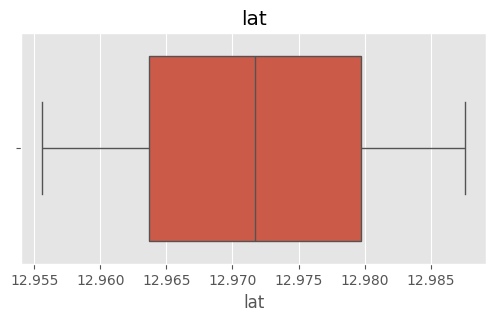

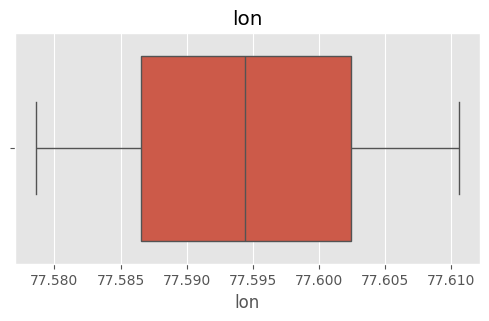

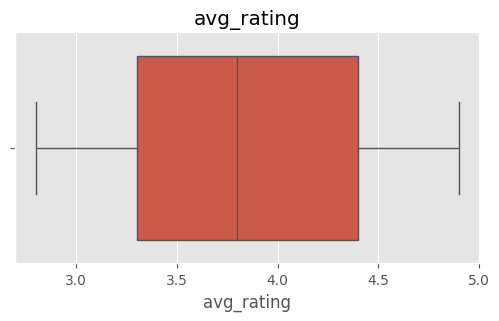

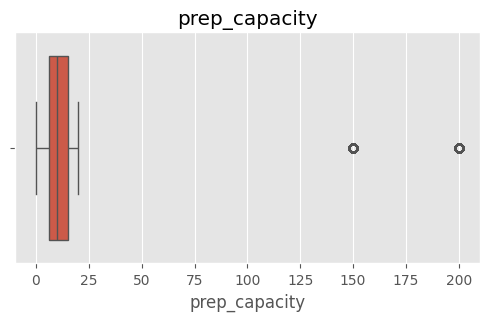

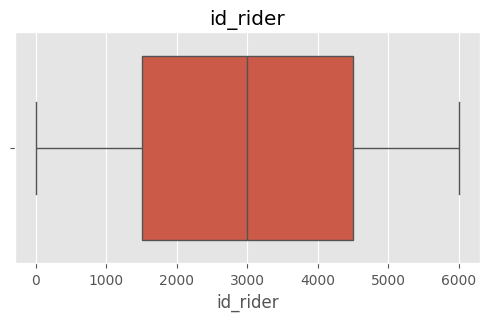

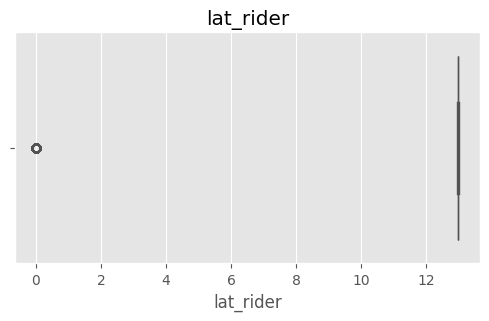

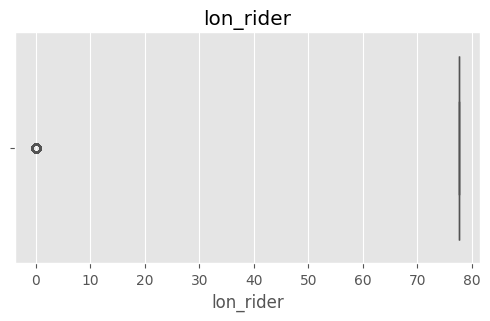

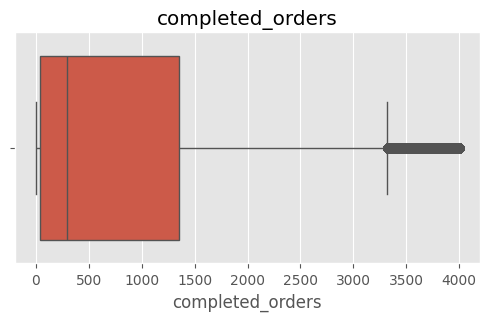

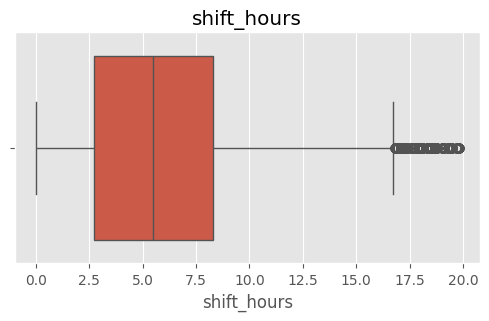

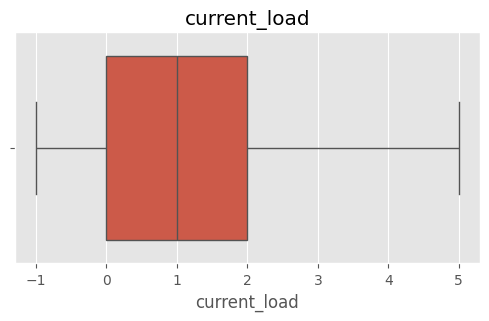

In [21]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

<Axes: >

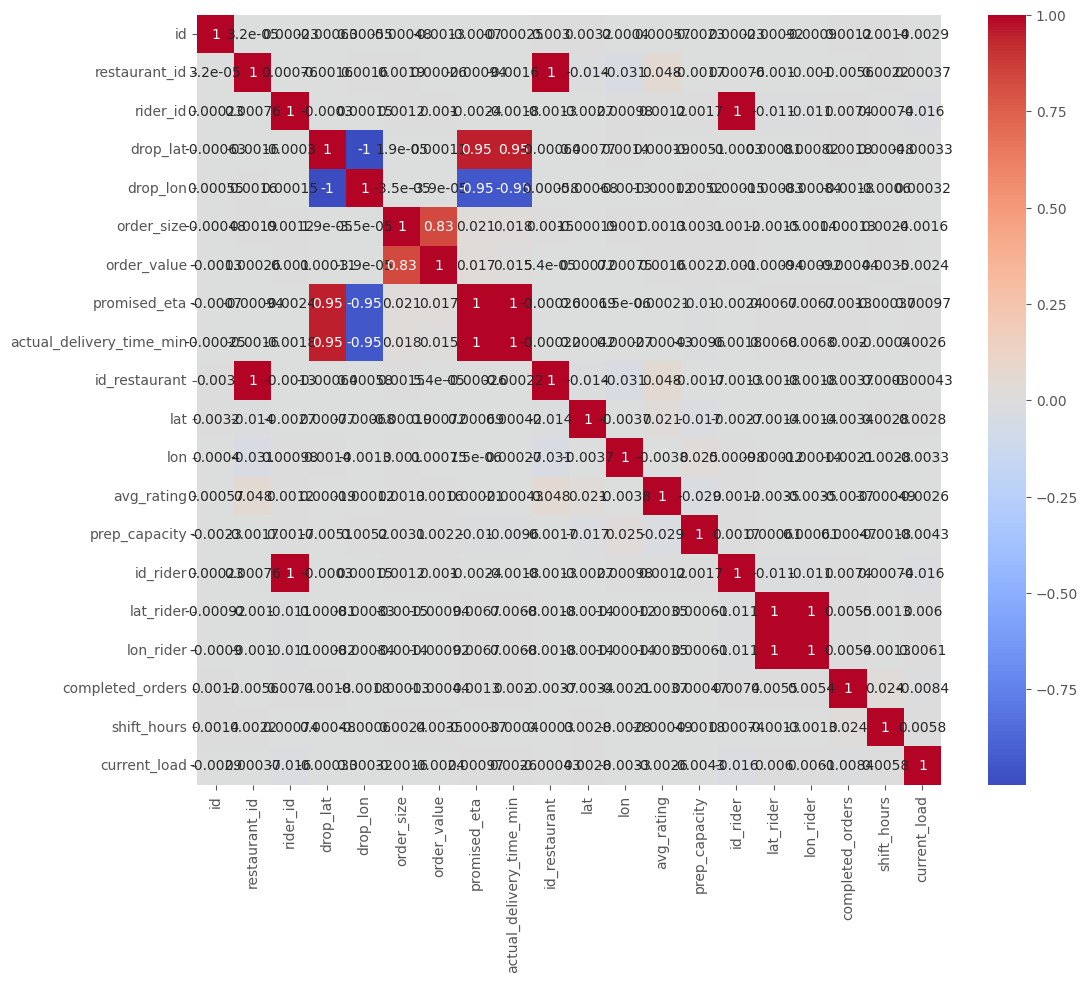

In [22]:
plt.figure(figsize=(12,10))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

<Axes: xlabel='vehicle_type', ylabel='count'>

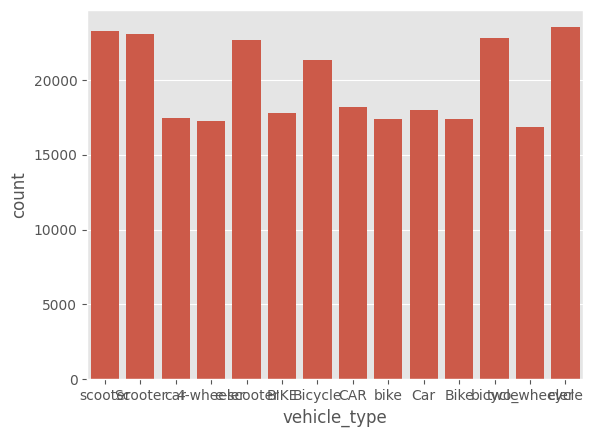

In [23]:
sns.countplot(data=data,x="vehicle_type")

<Axes: xlabel='cuisine', ylabel='count'>

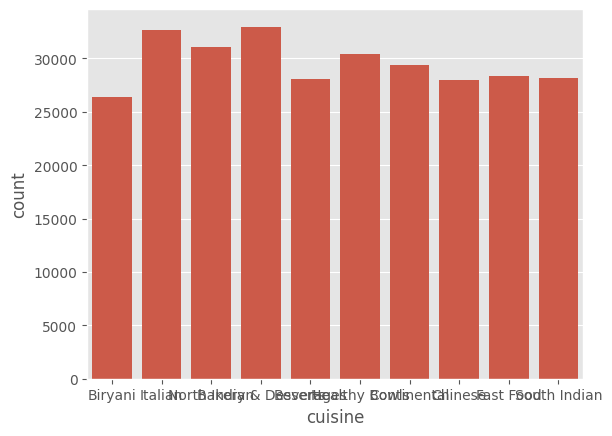

In [24]:
sns.countplot(data=data,x="cuisine")

<Axes: xlabel='actual_delivery_time_min', ylabel='Count'>

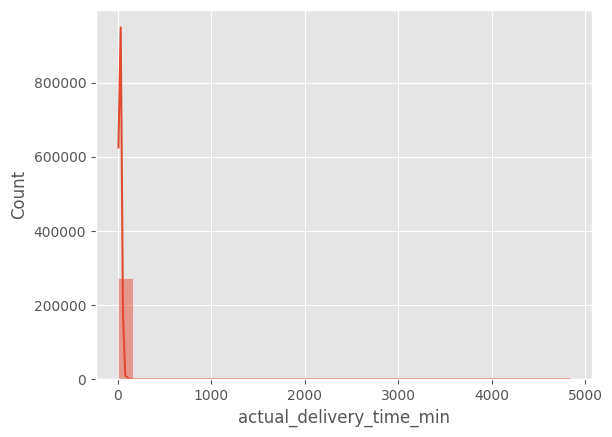

In [25]:
sns.histplot(
    data["actual_delivery_time_min"],
    bins=30,
    kde=True
)

In [26]:
data.to_csv("merged_data.csv",index=False)